# MindBridge: Problem Understanding  
### Defining the Problem

---

> **Goal**  
> Classify mental health status from social media text using **Natural Language Processing (NLP)** and **Machine Learning**.

---

### Problem Overview

| **Property** | **Description** |
|-------------|----------------|
| **Task Type** | Multi-class Text Classification |
| **Input** | Raw social media text *(Reddit posts, tweets)* |
| **Output** | One of **7 mental health status labels** |
| **Approach** | NLP Preprocessing → TF-IDF → Classical ML Models |
| **Dataset** | ~53,000 labeled samples *(Kaggle)* |

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("darkgrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
df = pd.read_csv('data/Combined_Data.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.columns = ['statement', 'status']
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df = df.reset_index(drop=True)

print("MINDBRIDGE — DATASET OVERVIEW")
print()
print(f"  Total Samples     : {len(df):,}")
print(f"  Total Features    : {df.shape[1]}")
print(f"  Missing Values    : {df.isnull().sum().sum()}")
print(f"  Duplicate Rows    : {df.duplicated().sum():,}")
print(f"  Unique Classes    : {df['status'].nunique()}")
print()
print(f"Output Classes ({df['status'].nunique()} total):\n")
for i, cls in enumerate(sorted(df['status'].unique()), 1):
    count = df['status'].value_counts()[cls]
    pct = count / len(df) * 100
    bar = "█" * int(pct / 2)
    print(f"   {i}. {cls:<25} {bar} {pct:.1f}%")


MINDBRIDGE — DATASET OVERVIEW

  Total Samples     : 51,093
  Total Features    : 2
  Missing Values    : 0
  Duplicate Rows    : 0
  Unique Classes    : 7

Output Classes (7 total):

   1. Anxiety                   ███ 7.1%
   2. Bipolar                   ██ 4.9%
   3. Depression                ██████████████ 29.5%
   4. Normal                    ███████████████ 31.4%
   5. Personality disorder       1.8%
   6. Stress                    ██ 4.5%
   7. Suicidal                  ██████████ 20.8%


In [3]:
from IPython.display import HTML, display

def render_mindbridge_problem_statement():
    html = """
    <style>
        .mb-wrapper {
            font-family: 'Segoe UI', sans-serif;
            margin: 18px 0;
        }

        .mb-card {
            background: #111827;
            border: 1px solid rgba(255,255,255,0.08);
            border-radius: 20px;
            padding: 34px 38px;
            color: #f9fafb;
            box-shadow: 0 10px 30px rgba(0, 0, 0, 0.22);
        }

        .mb-tag {
            display: inline-block;
            padding: 6px 12px;
            font-size: 12px;
            font-weight: 600;
            color: #c4b5fd;
            background: rgba(139, 92, 246, 0.12);
            border: 1px solid rgba(139, 92, 246, 0.20);
            border-radius: 999px;
            margin-bottom: 18px;
            letter-spacing: 0.3px;
        }

        .mb-title {
            font-size: 30px;
            font-weight: 700;
            margin: 0 0 8px 0;
            color: #ffffff;
        }

        .mb-subtitle {
            font-size: 15px;
            color: #9ca3af;
            margin: 0 0 28px 0;
            line-height: 1.6;
            max-width: 820px;
        }

        .mb-grid-2 {
            display: grid;
            grid-template-columns: 1fr 1fr;
            gap: 16px;
            margin-bottom: 24px;
        }

        .mb-panel {
            background: rgba(255,255,255,0.03);
            border: 1px solid rgba(255,255,255,0.06);
            border-radius: 16px;
            padding: 18px 18px;
        }

        .mb-panel-label {
            font-size: 13px;
            font-weight: 700;
            color: #a78bfa;
            text-transform: uppercase;
            letter-spacing: 0.6px;
            margin-bottom: 10px;
        }

        .mb-panel-text {
            font-size: 14px;
            color: #e5e7eb;
            line-height: 1.7;
        }

        .mb-flow {
            display: grid;
            grid-template-columns: repeat(4, 1fr);
            gap: 14px;
            margin-bottom: 24px;
        }

        .mb-step {
            background: rgba(255,255,255,0.025);
            border: 1px solid rgba(255,255,255,0.05);
            border-radius: 16px;
            padding: 18px 14px;
            text-align: center;
            transition: all 0.2s ease;
        }

        .mb-step:hover {
            transform: translateY(-2px);
            border-color: rgba(167,139,250,0.35);
        }

        .mb-step-number {
            width: 30px;
            height: 30px;
            line-height: 30px;
            margin: 0 auto 10px auto;
            border-radius: 50%;
            background: rgba(139, 92, 246, 0.14);
            color: #c4b5fd;
            font-size: 13px;
            font-weight: 700;
        }

        .mb-step-title {
            font-size: 15px;
            font-weight: 650;
            color: #ffffff;
            margin-bottom: 6px;
        }

        .mb-step-text {
            font-size: 13px;
            color: #9ca3af;
            line-height: 1.5;
        }

        .mb-footer {
            display: flex;
            flex-wrap: wrap;
            gap: 10px;
            margin-top: 4px;
        }

        .mb-chip {
            font-size: 12px;
            color: #d1d5db;
            background: rgba(255,255,255,0.04);
            border: 1px solid rgba(255,255,255,0.06);
            padding: 8px 12px;
            border-radius: 999px;
        }

        @media (max-width: 900px) {
            .mb-grid-2,
            .mb-flow {
                grid-template-columns: 1fr;
            }
        }
    </style>

    <div class="mb-wrapper">
        <div class="mb-card">
            <div class="mb-tag">NLP TEXT CLASSIFICATION PROJECT</div>

            <h2 class="mb-title">MindBridge: Problem Statement</h2>
            <p class="mb-subtitle">
                MindBridge aims to analyze user-written text and classify it into one of seven mental health-related categories,
                enabling early emotional risk awareness through Natural Language Processing and Machine Learning.
            </p>

            <div class="mb-grid-2">
                <div class="mb-panel">
                    <div class="mb-panel-label">Objective</div>
                    <div class="mb-panel-text">
                        Build an NLP system that automatically classifies social media text into mental health status categories
                        such as stress, anxiety, depression, and suicidal risk.
                    </div>
                </div>

                <div class="mb-panel">
                    <div class="mb-panel-label">Why It Matters</div>
                    <div class="mb-panel-text">
                        Language often reflects emotional struggle before visible intervention happens.
                        A system like MindBridge can support early awareness and encourage timely support.
                    </div>
                </div>
            </div>

            <div class="mb-flow">
                <div class="mb-step">
                    <div class="mb-step-number">1</div>
                    <div class="mb-step-title">Input</div>
                    <div class="mb-step-text">Raw social media or user-written text</div>
                </div>

                <div class="mb-step">
                    <div class="mb-step-number">2</div>
                    <div class="mb-step-title">Preprocess</div>
                    <div class="mb-step-text">Clean and transform text into structured features</div>
                </div>

                <div class="mb-step">
                    <div class="mb-step-number">3</div>
                    <div class="mb-step-title">Classify</div>
                    <div class="mb-step-text">Use TF-IDF and ML models to predict the category</div>
                </div>

                <div class="mb-step">
                    <div class="mb-step-number">4</div>
                    <div class="mb-step-title">Support</div>
                    <div class="mb-step-text">Promote early awareness and safer intervention pathways</div>
                </div>
            </div>

            <div class="mb-footer">
                <div class="mb-chip">~53,000 samples</div>
                <div class="mb-chip">7 classes</div>
                <div class="mb-chip">TF-IDF + ML Models</div>
                <div class="mb-chip">Macro F1 as key metric</div>
            </div>
        </div>
    </div>
    """
    display(HTML(html))

render_mindbridge_problem_statement()

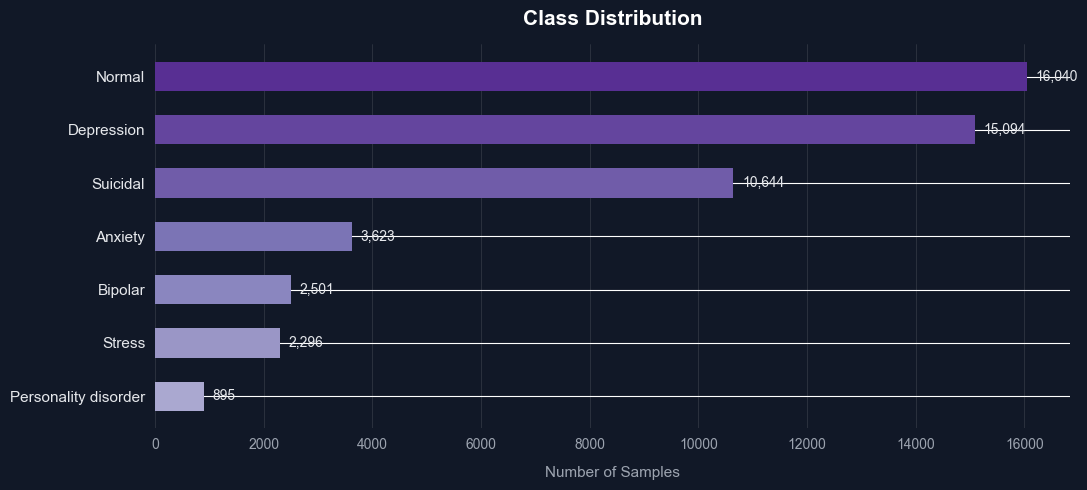

Plot saved!!


In [4]:
class_counts = df['status'].value_counts().sort_values(ascending=True)

base_color = "#8b5cf6"   # soft violet (primary)
accent_color = "#a78bfa" # lighter accent
muted_color = "#374151"  # muted gray

colors = plt.cm.Purples(np.linspace(0.45, 0.85, len(class_counts)))

fig, ax = plt.subplots(figsize=(11, 5))

fig.patch.set_facecolor('#111827')
ax.set_facecolor('#111827')

bars = ax.barh(
    class_counts.index,
    class_counts.values,
    color=colors,
    height=0.55,
    edgecolor='none'
)

for bar, val in zip(bars, class_counts.values):
    ax.text(
        val + max(class_counts.values)*0.01,
        bar.get_y() + bar.get_height()/2,
        f'{val:,}',
        va='center',
        ha='left',
        color='#e5e7eb',
        fontsize=10,
        fontweight='medium'
    )

ax.set_title(
    'Class Distribution',
    color='white',
    fontsize=15,
    fontweight='semibold',
    pad=14
)

ax.set_xlabel(
    'Number of Samples',
    color='#9ca3af',
    fontsize=11,
    labelpad=10
)

ax.tick_params(axis='x', colors='#9ca3af')
ax.tick_params(axis='y', colors='#e5e7eb')

for spine in ax.spines.values():
    spine.set_visible(False)

ax.xaxis.grid(True, linestyle='-', linewidth=0.5, alpha=0.15)
ax.set_axisbelow(True)


for label in ax.get_yticklabels():
    label.set_fontsize(11)
    label.set_fontweight('medium')

plt.tight_layout()


plt.savefig(
    'results/plots/class_distribution.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='#111827'
)

plt.show()

print("Plot saved!!")

In [5]:
df['word_count'] = df['statement'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['statement'].apply(lambda x: len(str(x)))

stats = df.groupby('status')[['word_count', 'char_count']].describe().round(2)

html_rows = ""
for cls in sorted(df['status'].unique()):
    wc = df[df['status'] == cls]['word_count']
    cc = df[df['status'] == cls]['char_count']
    html_rows += f"""
    <tr>
        <td style="padding:10px 16px; color:#48CAE4; font-weight:bold;">{cls}</td>
        <td style="padding:10px 16px; text-align:center;">{wc.mean():.1f}</td>
        <td style="padding:10px 16px; text-align:center;">{wc.min():.0f}</td>
        <td style="padding:10px 16px; text-align:center;">{wc.max():.0f}</td>
        <td style="padding:10px 16px; text-align:center;">{wc.std():.1f}</td>
        <td style="padding:10px 16px; text-align:center;">{cc.mean():.1f}</td>
        <td style="padding:10px 16px; text-align:center;">{cc.max():.0f}</td>
    </tr>
    """

html = f"""
<div style="
    background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%);
    border-radius: 16px;
    padding: 28px 36px;
    font-family: 'Segoe UI', sans-serif;
    color: white;
    border-left: 6px solid #6C63FF;
    margin: 10px 0;
">
    <h2 style="color:#6C63FF; margin-bottom:4px;">Text Statistics by Class</h2>
    <p style="color:#aaa; font-size:13px; margin-bottom:20px;">Summary of word and character counts per mental health category</p>
    <table style="width:100%; border-collapse:collapse;">
        <thead>
            <tr style="border-bottom: 1px solid rgba(108,99,255,0.4);">
                <th style="padding:10px 16px; text-align:left; color:#6C63FF;">Class</th>
                <th style="padding:10px 16px; text-align:center; color:#6C63FF;">Avg Words</th>
                <th style="padding:10px 16px; text-align:center; color:#6C63FF;">Min Words</th>
                <th style="padding:10px 16px; text-align:center; color:#6C63FF;">Max Words</th>
                <th style="padding:10px 16px; text-align:center; color:#6C63FF;">Std Words</th>
                <th style="padding:10px 16px; text-align:center; color:#6C63FF;">Avg Chars</th>
                <th style="padding:10px 16px; text-align:center; color:#6C63FF;">Max Chars</th>
            </tr>
        </thead>
        <tbody>
            {html_rows}
        </tbody>
    </table>
</div>
"""
display(HTML(html))
print("Summary statistics by class computed successfully.")

Class,Avg Words,Min Words,Max Words,Std Words,Avg Chars,Max Chars
Anxiety,143.1,1,1592,152.1,761.2,8539
Bipolar,178.3,4,4804,180.9,958.1,26163
Depression,168.2,1,4239,188.4,844.8,19822
Normal,17.4,1,255,22.8,91.2,1358
Personality disorder,177.9,5,5419,233.1,949.4,27588
Stress,111.7,1,1606,101.1,594.0,8389
Suicidal,146.5,1,6300,187.0,735.4,32759


Summary statistics by class computed successfully.


## Key Takeaways

| Finding | Detail |
|---------|--------|
| **Dataset Size** | ~53,000 samples after cleaning |
| **Classes** | 7 distinct mental health states confirmed |
| **Task** | Multi-class NLP classification |
| **Key Challenge** | Class imbalance — will handle in preprocessing |
| **Success Metric** | Macro F1 Score (accounts for imbalance) |